In [1]:
import pickle

from matplotlib import pyplot as plt
import pandas as pd

from config import PATHS, PatientDir
from cycle_extraction.cycle_functions import plot_phase_histogram_for_single_feature
from written_thesis.helpers import PRETTY_FEATURE_NAMES_MAP, rename_patient

In [2]:
combinations = [
    (
        PatientDir(PATHS.competition_dir / 'competition-2'),
        ['seizures', 'CNN FPs'],
        'acfw_D',
    ),
    (
        PatientDir(PATHS.ultra2_dir / 'U002-DE01-17'),
        ['seizures', 'ensemble FPs'],
        'Alpha_P',
    ),
    (
        PatientDir(PATHS.ultra2_dir / 'U002-DE01-17'),
        ['seizures', 'ensemble FPs'],
        'Beta_P',
    ),
]

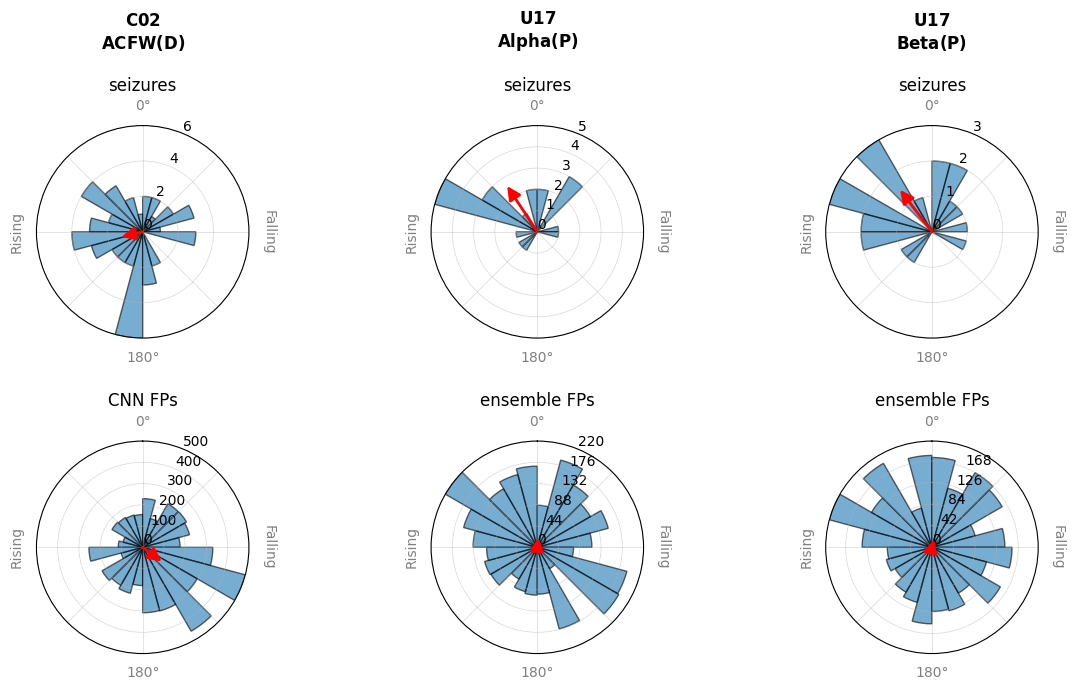

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=len(combinations), subplot_kw={'projection': 'polar'}, figsize=(12, 7))

for col, combination in enumerate(combinations):
    pdir, event_types, feat = combination

    # load data
    metrics = pd.read_pickle(pdir.cycle_extraction_metrics_table.pickle)
    with pdir.event_phases_per_type_per_feat.open('rb') as f:
        event_phases_per_type_per_feat = pickle.load(f)

    for row, event_type in enumerate(event_types):
        event_phases = event_phases_per_type_per_feat[event_type][feat]

        m = metrics.loc[:, event_type]
        plv = m['plv'].to_dict()[feat]
        mean_angle = m['mean_angle'].to_dict()[feat]
        p_rayleigh_bh = m['p_rayleigh_bh'].to_dict()[feat]

        ax = axes[row, col]
        plot_phase_histogram_for_single_feature(ax, event_phases, plv, mean_angle)

        if row == 0:
            ax.set_title(f'$\\mathbf{{{rename_patient(pdir.name)}}}$\n' # patient
                         f'$\\mathbf{{{PRETTY_FEATURE_NAMES_MAP[feat]}}}$\n\n' # feature
                         f'{event_type}', # event type
                         )
        elif row == 1:
            ax.set_title(event_type)


fig.tight_layout(h_pad=2, w_pad=1,)